<a href="https://colab.research.google.com/github/shao-chen-1106/ColabRep/blob/main/%E5%AD%B8%E7%BF%92OpenCV%E8%A6%96%E8%A6%BA%E8%88%87Python%E9%82%8F%E8%BC%AF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌟 第二週課程總覽：從「看見圖片」到「邏輯判斷」

* **核心精神**：打破「修圖軟體」的思維，建立「圖片 = 數字矩陣」的工程師視角，並導入 Python 最核心的 `If/Else` 決策邏輯。最後，引導學生建立面對未來 AI 時代的「自我學習」心態。

---




## 第一節 (W2-S1)：OpenCV 基礎與模組 (45 分鐘)





### 👨‍🏫 教學過程細節與引導話術

* **0-10 min：災難與救贖 (Import)**
* **老師操作**：讓學生執行沒有 `import cv2` 的程式碼，觸發 `NameError`。
* **引導話術**：「Python 剛打開時就像一個空的工作台，它很聰明但沒有眼睛。看到紅字不要怕，這代表電腦在跟你求救說：『我不認識 cv2 是什麼！』。請大家把視覺專用瑞士刀 `import` 拿進來。」


* **10-25 min：駭客任務 (形狀與陣列)**
* **老師操作**：印出圖片的 `shape` 與真實矩陣數字。
* **引導話術**：「大家看這個 `(720, 1280, 3)`。這不是一張照片，這是一個有 720 列、1280 行，而且每個格子裡疊了 3 層數字（藍、綠、紅）的超級大 Excel 表格！電腦只看得到這些 0 到 255 的數字。」


* **25-45 min：數位外科手術 (矩陣切片與填色挑戰)**
* **老師操作**：講解切片座標的陷阱。
* **引導話術**：「注意！數學課是 (X, Y)，但電腦陣列是 **[列(Y), 行(X)]**，先切上下、再切左右。現在請大家運用這個觀念，完成講義裡的『黃色色塊』挑戰！」


### 💻 學生版 Colab 講義程式碼 (W2-S1)

*(學生需自行思考並填寫 `???` 才能執行成功)*

✅ 步驟 1 完成：已經從網路取得檔案 test.jpg
✅ 成功裝備視覺瑞士刀！OpenCV 版本： 4.13.0
這張圖片的形狀 (高, 寬, 色彩通道) 是： (720, 1280, 3)
左上角的一小塊真實像素數字：
 [[[38 48 72]
  [40 50 74]]

 [[37 47 71]
  [37 47 71]]]


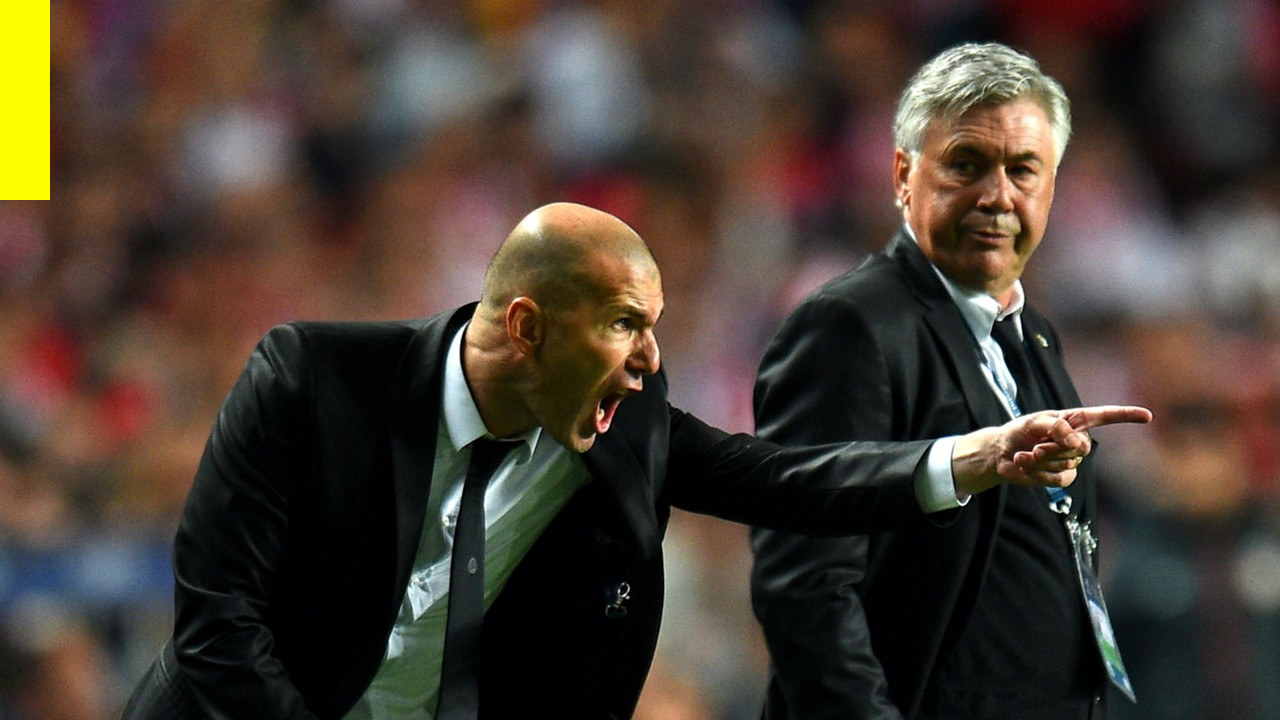

In [21]:
# ==========================================
# W2-S1 區塊 1：認識 Import 與駭客任務
# ==========================================
# 1. 準備素材 (Linux 指令下載圖片)
!wget -q -O test.jpg https://raw.githubusercontent.com/ultralytics/yolov5/master/data/images/zidane.jpg
print("✅ 步驟 1 完成：已經從網路取得檔案 test.jpg")

# 2. 由工具箱，準備取出工具，拿出視覺瑞士刀 (請填空???)
# 【任務】：Python 預設看不懂圖片，請將 ??? 改成正確的單字 (提示：拿進來/輸入)
import cv2
from google.colab.patches import cv2_imshow # Colab 專用顯示螢幕
print("✅ 成功裝備視覺瑞士刀！OpenCV 版本：", cv2.__version__)

# 3. 讀取圖片並檢查身分
img = cv2.imread('test.jpg')
print("這張圖片的形狀 (高, 寬, 色彩通道) 是：", img.shape)
print("左上角的一小塊真實像素數字：\n", img[0:2, 0:2])

# ==========================================
# W2-S1 區塊 2：🏆 課堂大挑戰 (數位外科手術)
# ==========================================
# 任務：請在原始圖片 (img) 上，畫出一個「黃色」的實心色塊。
# 條件 1：色塊的高度 (Y) 要在 50 到 200 之間。
# 條件 2：色塊的寬度 (X) 要在 100 到 400 之間。

# 💡 提示：
# - 陣列座標順序是 [Y起點:Y終點, X起點:X終點]
# - OpenCV 的顏色順序是 (B藍, G綠, R紅)，數值是 0~255。
# - 黃色 = 綠光 + 紅光 (藍光要關閉)

# 👇 請將下方的 ??? 替換成正確的數字，寫錯會報錯喔！ 👇

img[ 0 : 200 , 0 : 50 ] = ( 0 , 255 , 255 )

# 👆 填寫完畢後按下執行，看看有沒有成功出現黃色色塊！👆
cv2_imshow(img)

---

## 第二節 (W2-S2)：教電腦做決定 (If/Else) (45 分鐘)



### 👨‍🏫 教學過程細節與引導話術

* **0-15 min：邏輯分流與縮排觀念**
* **引導話術**：「我們剛剛都在『命令』電腦做事。現在我們要『教』電腦自己做決定。如果條件成立走左邊，不成立走右邊。請特別注意 Python 的靈魂——**縮排 (Indentation)**，空四格代表『這句話歸 if 管』，忘記打冒號一定會報錯！」


* **15-30 min：測量圖片與邏輯判斷**
* **老師操作**：抓出圖片的長寬，教電腦判斷這是一張風景照還是直立照。
* **引導話術**：「我們可以用 `img.shape[0]` 抓出高度，`img.shape[1]` 抓出寬度。請大家寫下邏輯，讓電腦自己告訴我們這張圖是橫的還是直的。」


* **30-45 min：終極 Boss 戰 (中心點顏色探測)**
* **老師操作**：帶入 AI 辨識的底層邏輯，讓學生抓出中心點，判斷特定顏色的強弱。
* **引導話術**：「這就是 AI 辨識的雛形！我們抓出圖片正中央的那個像素點，看看它的『紅色』數值有沒有超過 100。請完成最後的挑戰！」





### 💻 學生版 Colab 講義程式碼 (W2-S2)

In [23]:
# ==========================================
# W2-S2 區塊 1：暖身 (Python 縮排與 If/Else)
# ==========================================
# 老師說：Python 最看重「縮排」與「冒號」。

score = int(input("請輸入你的自然科分數 (0~100)："))

# 注意行尾的「冒號 :」和下一行的「縮排」
if score >= 60:
    print("太棒了！邏輯及格，可以安心玩 AI！")
else:
    print("沒關係，今天學完 Python 你就會變 100 分！")

# ==========================================
# W2-S2 區塊 2：判斷圖片是「橫的」還是「直的」
# ==========================================
# 重新讀取一次乾淨的圖片
img = cv2.imread('test.jpg')

# img.shape 會吐出 (高度, 寬度, 色彩層)
height = img.shape[0]  # 第 0 個位置是高度
width = img.shape[1]   # 第 1 個位置是寬度
print(f"這張圖的高度是 {height}，寬度是 {width}")

# 👇 任務：如果 寬度 大於 高度，印出橫向；否則印出直向 👇
# 請填入正確的變數名稱與語法

if width > height :
    print("💡 電腦判斷：這是一張『橫向 (風景)』的照片！")
else :
    print("💡 電腦判斷：這是一張『直向 (手機)』的照片！")

# ==========================================
# W2-S2 區塊 3：🏆 終極挑戰 (探測正中央的顏色)
# ==========================================
# 任務：找出圖片正中央的像素點，判斷它的「紅色 (Red)」數值有沒有超過 100。

# 1. 找出正中央的座標 (// 代表除法並無條件捨去小數點)
center_y = height // 2
center_x = width // 2

# 2. 抓出該點的 B, G, R 數值 (注意 OpenCV 是 BGR 順序！)
b, g, r = img[center_y, center_x]
print(f"正中央像素的數值 -> 藍:{b}, 綠:{g}, 紅:{r}")

# 👇 請完成下方的 If/Else 判斷式 👇
# 提示：我們要檢查的是「紅色變數 (r)」有沒有大於 100

if r > 100 :
    print("🔥 偵測結果：這個點的紅色很強烈！")
else :
    print("💧 偵測結果：這個點的紅色不夠強...")

請輸入你的自然科分數 (0~100)：67
太棒了！邏輯及格，可以安心玩 AI！
這張圖的高度是 720，寬度是 1280
💡 電腦判斷：這是一張『橫向 (風景)』的照片！
正中央像素的數值 -> 藍:34, 綠:60, 紅:100
💧 偵測結果：這個點的紅色不夠強...


### 進階版本
如何畫出該點的**空心正方形**?

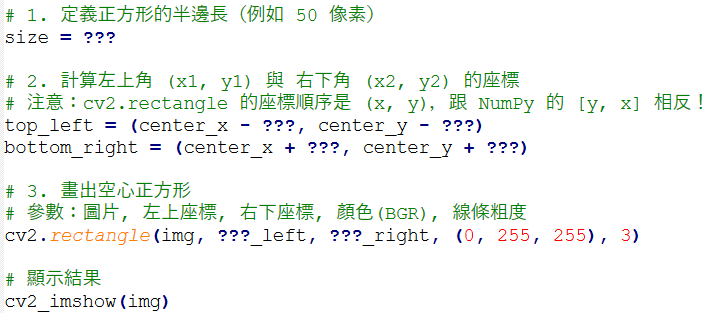

參考網址: https://gemini.google.com/share/029bbd11a2cb

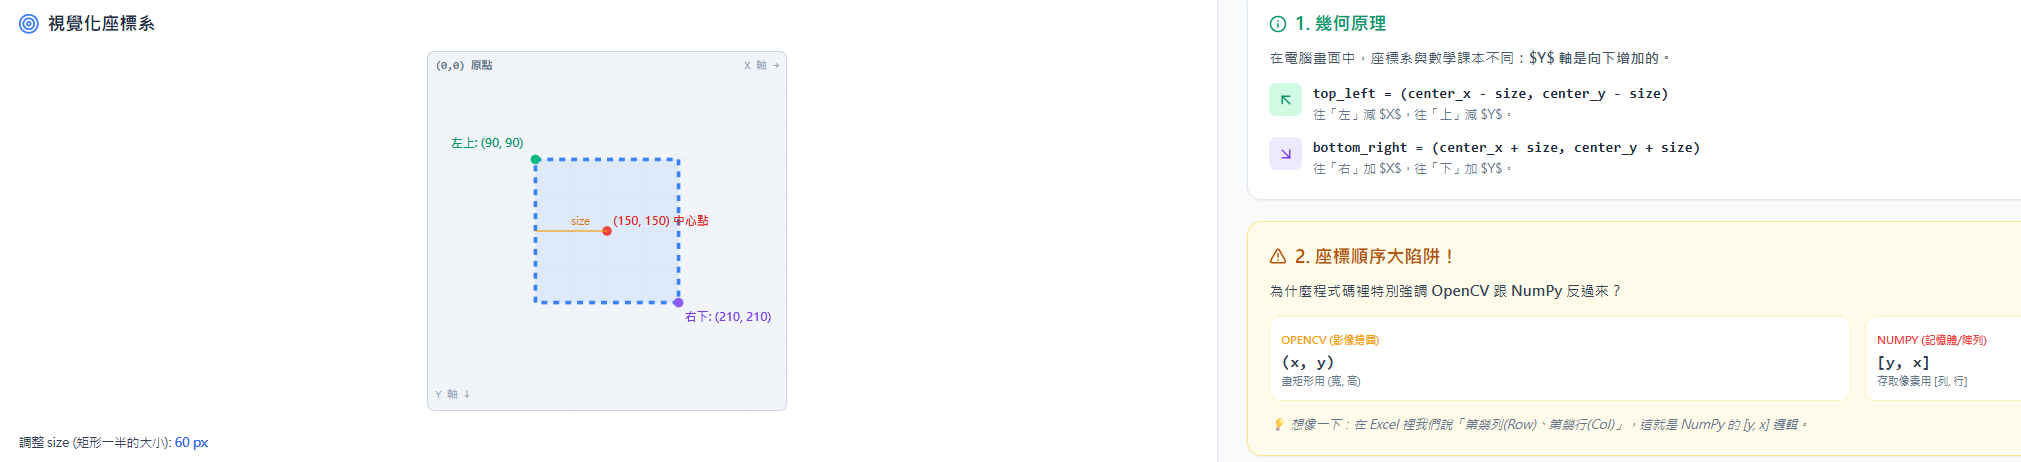

---

## 📝 課後收斂：學習心得與「自我學習」反思

在自然組的養成過程中，「給答案」不如「給釣竿」。這段程式碼不僅要求學生回顧技術，更加入了對「自我學習」的反思。強烈建議加在講義最下方。

In [ ]:
# ==========================================
# 📝 第二週學習心得與自我學習反思 (存檔前必做！)
# ==========================================
print("【第一部分：技術回顧】\n")

# 問題 1：駭客視角
q1 = input("1. 上完今天的課，你現在知道電腦眼中的「圖片」到底是什麼東西了嗎？\n你的回答：")

# 問題 2：AI 想像力
q2 = input("\n2. 我們今天用 If/Else 判斷了圖片特定位置的顏色。如果你在開發「自動駕駛 AI」，你覺得可以用類似的邏輯來判斷馬路上的什麼東西？\n你的回答：")

print("\n------------------------------------------")
print("【第二部分：自我學習的覺醒】\n")
print("老師的話：AI 的技術每幾個月就會翻新一次。我們現在學的工具，可能五年後就淘汰了。")
print("在未來的世界裡，『遇到不會的東西，自己找答案的能力』比死背語法更重要。\n")

# 問題 3：自我除錯與學習
q3 = input("3. 今天在填寫 ??? 或執行程式時，你一定有遇到「紅字報錯 (Error)」。當未來沒有老師在旁邊幫你時，你打算用什麼方法找出程式碼的錯誤並解決它？（例如：查資料、看懂錯誤訊息、問 AI...）\n你的回答：")

print("\n==========================================")
print(f"🌟 你的學習軌跡已記錄！")
print("記住：紅字報錯不是失敗，而是電腦在跟你溝通的橋樑。擁抱錯誤，就是進步的開始。")
print("==========================================")
print("🚨 【重要提醒】：請點選左上角「檔案」->「在雲端硬碟中儲存副本」，把這份筆記存下來！下週見！")

👨‍🏫 給老師的課堂特別叮嚀：給自然組學生的 3 個學習提示
您可以在學生寫心得時，將這三點提示投影在黑板上，當作這週的結語：



1.   「Error 是工程師的日常，不是扣分項目」：在高中考試裡，寫錯答案會被扣分；但在寫程式時，紅色的 Error 訊息是你的導航儀。學會不害怕紅字，甚至學會「閱讀」紅字，是成為高手的關鍵。更重要的是，如果沒有將錯就錯，充眼陌路，視而不見，就會**錯越多，越厲害**。

2.   「邏輯大於語法 (Logic > Syntax)」：忘記 cv2.imread 怎麼拼沒關係，Google 或問 AI 一秒鐘就有了。但是「該怎麼判斷顏色」、「該怎麼裁切矩陣」這種解題的邏輯步驟，是 AI 無法完全取代的，這也是自然組學生最強的武器。

3.   「建立自己的知識庫」：善用 GitHub 與 Colab，把每一次的失敗與成功都記錄下來。當你學會自己找答案，你就具備了跟著這個 AI 時代一起進化的能力。





---

# 學習心得

1.   心得1
2.   心得2

